# APH/PPH split proportions artifact vs csv

## Setup

In [1]:
import pandas as pd, numpy as np, os
from vivarium import Artifact
import db_queries
from get_draws.api import get_draws
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
from vivarium_gates_mncnh.constants import paths

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning) 

In [3]:
# Parameters cell for papermill
model_dir = "model34.0"

In [4]:
base_artifacts_dir = Path("/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/") / model_dir

In [5]:
artifact_paths = {p.stem.title(): p for p in base_artifacts_dir.iterdir()}
artifact_paths

{'Nigeria': PosixPath('/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model34.0/nigeria.hdf'),
 'Pakistan': PosixPath('/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model34.0/pakistan.hdf'),
 'Ethiopia': PosixPath('/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model34.0/ethiopia.hdf')}

In [6]:
locations = list(artifact_paths.keys())
locations

['Nigeria', 'Pakistan', 'Ethiopia']

In [7]:
location_ids = db_queries.get_ids('location')
location_ids = location_ids.loc[location_ids.location_name.str.lower().isin([x.lower() for x in locations])]
location_ids

,location_id,location_name,location_type,location_description
139,165,Pakistan,admin0,admin0
150,179,Ethiopia,admin0,admin0
183,214,Nigeria,admin0,admin0


In [8]:
draws_we_simulate = [22, 60, 71, 79, 115, 118, 146, 167, 197, 244]
draws_we_simulate = ["draw_"+str(x) for x in draws_we_simulate]
draws_we_simulate

['draw_22',
 'draw_60',
 'draw_71',
 'draw_79',
 'draw_115',
 'draw_118',
 'draw_146',
 'draw_167',
 'draw_197',
 'draw_244']

In [9]:
def load_yaml_file(path):
    with open(path) as stream:
        return yaml.safe_load(stream)

In [10]:
def read_artifact(key, filter_terms=['sex == Female' , 'age_start > 5', 'age_end < 60']):
    all_locations_data = []
    for location in locations:
        art = Artifact(artifact_paths[location], filter_terms=filter_terms)
        location_data = art.load(key)
        if not isinstance(location_data, pd.DataFrame):
            location_data = pd.DataFrame({'value': location_data, 'location': location}, index=[0]).set_index('location')
        else:
            location_data['location'] = location
            location_data = location_data.reset_index().set_index(['location'] + [c for c in location_data.index.names if c is not None])
        all_locations_data.append(location_data)

    all_locations_data = pd.concat(all_locations_data)
    #if 'draw' in all_locations_data.columns[0]:
    #    all_locations_data = all_locations_data[[f'draw_{draw}' for draw in draws]]
    #else:
    #    for draw in draws:
    #        all_locations_data[f'draw_{draw}'] = all_locations_data['value']
    #    all_locations_data = all_locations_data.drop(columns='value')
    return all_locations_data

In [11]:
pp_frac = read_artifact('cause.maternal_hemorrhage.postpartum_fraction')[draws_we_simulate]
pp_frac

draw_22   draw_60  \
location sex    age_start age_end year_start year_end                       
Nigeria  Female 10.0      15.0    2023       2024      0.378630  0.335856   
                15.0      20.0    2023       2024      0.464318  0.333412   
                20.0      25.0    2023       2024      0.630371  0.513090   
                25.0      30.0    2023       2024      0.629444  0.358337   
                30.0      35.0    2023       2024      0.632015  0.776309   
                35.0      40.0    2023       2024      0.492241  0.584929   
                40.0      45.0    2023       2024      0.585348  0.863122   
                45.0      50.0    2023       2024      0.334798  0.359816   
                50.0      55.0    2023       2024      0.408492  0.528471   
Pakistan Female 10.0      15.0    2023       2024      0.378630  0.335856   
                15.0      20.0    2023       2024      0.464318  0.333412   
                20.0      25.0    2023       2024      0.630371  0.513090   
                25.0      30.0    2023       2024      0.629444  0.358337   
                30.0      35.0    2023       2024      0.632015  0.776309   
                35.0      40.0    2023       2024      0.492241  0.584929   
                40.0      45.0    2023       2024      0.585348  0.863122   
                45.0      50.0    2023       2024      0.334798  0.359816   
                50.0      55.0    2023       2024      0.408492  0.528471   
Ethiopia Female 10.0      15.0    2023       2024      0.378630  0.335856   
                15.0      20.0    2023       2024      0.464318  0.333412   
                20.0      25.0    2023       2024      0.630371  0.513090   
                25.0      30.0    2023       2024      0.629444  0.358337   
                30.0      35.0    2023       2024      0.632015  0.776309   
                35.0      40.0    2023       2024      0.492241  0.584929   
                40.0      45.0    2023       2024      0.585348  0.863122   
                45.0      50.0    2023       2024      0.334798  0.359816   
                50.0      55.0    2023       2024      0.408492  0.528471   

                                                        draw_71   draw_79  \
location sex    age_start age_end year_start year_end                       
Nigeria  Female 10.0      15.0    2023       2024      0.423964  0.340655   
                15.0      20.0    2023       2024      0.485447  0.325665   
                20.0      25.0    2023       2024      0.423330  0.514372   
                25.0      30.0    2023       2024      0.649476  0.540144   
                30.0      35.0    2023       2024      0.504693  0.633448   
                35.0      40.0    2023       2024      0.513600  0.434300   
                40.0      45.0    2023       2024      0.826107  0.688197   
                45.0      50.0    2023       2024      0.593542  1.000000   
                50.0      55.0    2023       2024      0.510028  0.550269   
Pakistan Female 10.0      15.0    2023       2024      0.423964  0.340655   
                15.0      20.0    2023       2024      0.485447  0.325665   
                20.0      25.0    2023       2024      0.423330  0.514372   
                25.0      30.0    2023       2024      0.649476  0.540144   
                30.0      35.0    2023       2024      0.504693  0.633448   
                35.0      40.0    2023       2024      0.513600  0.434300   
                40.0      45.0    2023       2024      0.826107  0.688197   
                45.0      50.0    2023       2024      0.593542  1.000000   
                50.0      55.0    2023       2024      0.510028  0.550269   
Ethiopia Female 10.0      15.0    2023       2024      0.423964  0.340655   
                15.0      20.0    2023       2024      0.485447  0.325665   
                20.0      25.0    2023       2024      0.423330  0.514372   
                25.0      30.0    2023       2024  

In [12]:
def describe_rowwise(df, percentiles=(0.025, 0.975)):
    # The pandas .describe() method describes columns
    # We can transpose before and after to describe rows instead
    return df.transpose().describe(percentiles=percentiles).transpose()

In [13]:
art = describe_rowwise(np.log(pp_frac))[["mean", "std"]].reset_index()
art = art[art.location == "Nigeria"].drop(columns=["location", "year_start", "year_end"]).set_index(["age_start", "age_end", "sex"]).reset_index()
art


,age_start,age_end,sex,mean,std
0,10.0,15.0,Female,-0.901251,0.253427
1,15.0,20.0,Female,-0.725183,0.323284
2,20.0,25.0,Female,-0.647418,0.182240
3,25.0,30.0,Female,-0.563616,0.212650
4,30.0,35.0,Female,-0.516298,0.189041
5,35.0,40.0,Female,-0.643466,0.211907
6,40.0,45.0,Female,-0.448552,0.284742
7,45.0,50.0,Female,-0.713447,0.527879
8,50.0,55.0,Female,-0.659077,0.173919


In [14]:
csv = pd.read_csv(paths.PPH_CROSSWALK_PARAMETERS_CSV)
csv = csv.set_index(["age_start", "age_end", "sex"])
csv = csv.rename(columns={"pred_diff_mean": "mean", "pred_diff_sd": "std"}).reset_index()
csv

,age_start,age_end,sex,mean,std
0,10.0,15.0,Female,-0.829067,0.314744
1,15.0,20.0,Female,-0.729488,0.188411
2,20.0,25.0,Female,-0.636943,0.181245
3,25.0,30.0,Female,-0.593641,0.213088
4,30.0,35.0,Female,-0.601271,0.229882
5,35.0,40.0,Female,-0.627765,0.210128
6,40.0,45.0,Female,-0.666090,0.311027
7,45.0,50.0,Female,-0.706105,0.549234
8,50.0,55.0,Female,-0.679698,0.165991


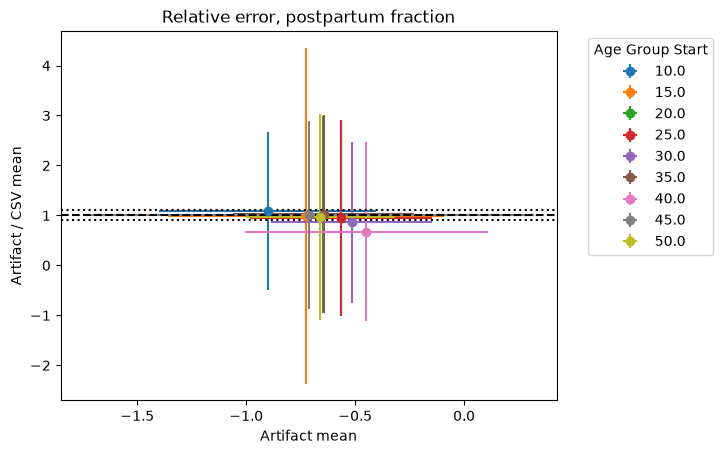

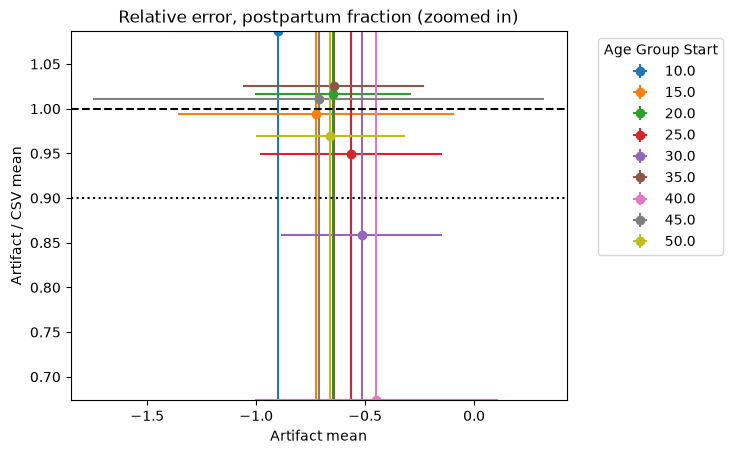

In [15]:
age_starts = art.age_start.unique()

for age in age_starts:
    art_for_age = art[art.age_start == age]
    csv_for_age = csv[csv.age_start == age]
    plt.errorbar(art_for_age["mean"], art_for_age["mean"] / csv_for_age["mean"], yerr=art_for_age["std"] / csv_for_age["std"] * 1.96, xerr=art_for_age["std"]*1.96, fmt='o', label=age)
plt.axhline(1, color='k', linestyle='--')
plt.axhline(1.1, color='k', linestyle='dotted')
plt.axhline(0.9, color='k', linestyle='dotted')
plt.xlabel(f'Artifact mean')
plt.ylabel('Artifact / CSV mean')
plt.title('Relative error, postpartum fraction')
plt.legend(title='Age Group Start', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for age in age_starts:
    art_for_age = art[art.age_start == age]
    csv_for_age = csv[csv.age_start == age]
    plt.errorbar(art_for_age["mean"], art_for_age["mean"] / csv_for_age["mean"], yerr=art_for_age["std"] / csv_for_age["std"] * 1.96, xerr=art_for_age["std"]*1.96, fmt='o', label=age)
plt.axhline(1, color='k', linestyle='--')
plt.axhline(1.1, color='k', linestyle='dotted')
plt.axhline(0.9, color='k', linestyle='dotted')
plt.ylim((art["mean"] / csv["mean"]).min(), (art["mean"] / csv["mean"]).max())
plt.xlabel(f'Artifact mean')
plt.ylabel('Artifact / CSV mean')
plt.title('Relative error, postpartum fraction (zoomed in)')
plt.legend(title='Age Group Start', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Note these values are surprisingly variable. We believe this is because the uncertainty is so large and we are only sampling 10 draws.